In [2]:
from scipy.optimize import fsolve
from scipy import stats
from scipy.optimize import curve_fit
from sympy import *
import numpy as np
import pandas as pd
from math import exp, pi, sqrt
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
#%pylab inline
%matplotlib inline

RF = pd.read_excel('rf_results_Sam_4_3_24.xlsx')
NN = pd.read_excel('nn_results_Sam_4_3_24.xlsx')

RF_trim = RF.loc[4:13, :]
NN_trim = NN.loc[4:13, :]

RF_PFT = RF.loc[4:6, :]
RF_biome = RF.loc[7:13, :]

NN_PFT = NN.loc[4:6, :]
NN_biome = NN.loc[7:13, :]

RF_trim_highR2 = RF_trim.loc[[4,6,7,9,10,12,13], :]
NN_trim_highR2 = NN_trim.loc[[4,6,7,9,10,12,13], :]

RF_PFT_highR2 = RF_trim.loc[[4,6], :]
RF_biome_highR2 = RF_trim.loc[[7,9,10,12,13], :]

NN_PFT_highR2 = NN_trim.loc[[4,6], :]
NN_biome_highR2 = NN_trim.loc[[7,9,10,12,13], :]

RF_trim_sort = RF_trim.reindex([4, 5, 6, 9, 8, 12, 10, 7, 13, 11])
NN_trim_sort = NN_trim.reindex([4, 5, 6, 9, 8, 12, 10, 7, 13, 11])


color1 = '#e41a1c'
color4 = '#377eb8'
color3 = '#4daf4a'
color2 = '#984ea3'

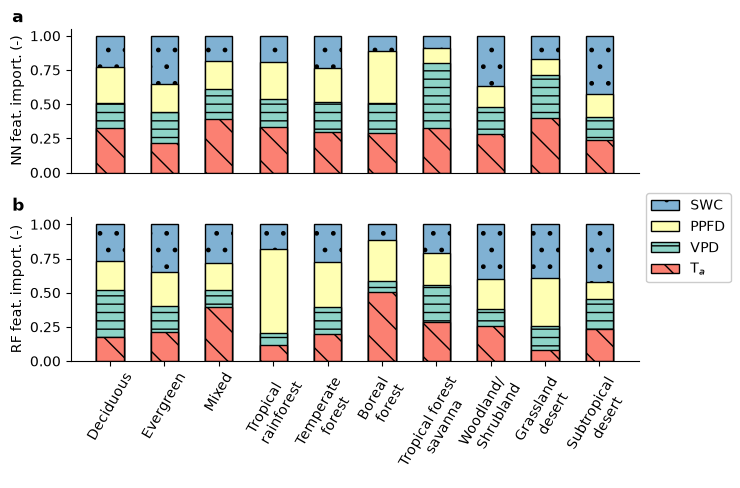

In [3]:
RF_trim = RF_trim_sort
NN_trim = NN_trim_sort

# Make the plot

r1 = np.arange(len(RF_trim['ta']))

barWidth = 0.5

color1 = '#fb8072'
color2 = '#8dd3c7'
color3 = '#ffffb3'
color4 = '#80b1d3'

hatch1 = '\\'
hatch2 = '--'
#hatch3 = 
hatch4 = '.'

fig = plt.figure(figsize = (7.5,5))
ax2 = plt.subplot2grid((2,1), (0,0))

ax2.bar(r1, NN_trim['ta']+NN_trim['vpd']+NN_trim['ppfd_in']+NN_trim['swc_shallow'], color=color4, hatch = hatch4, width=barWidth, edgecolor='k', label='SWC')
ax2.bar(r1, NN_trim['ta']+NN_trim['vpd']+NN_trim['ppfd_in'], color=color3,  width=barWidth, edgecolor='k', label='PPFD')
ax2.bar(r1, NN_trim['ta']+NN_trim['vpd'], color=color2, hatch = hatch2, width=barWidth, edgecolor='k', label='VPD')
ax2.bar(r1, NN_trim['ta'], color=color1, hatch = hatch1, width=barWidth, edgecolor='k', label='T$_a$')
ax2.set_ylabel('NN feat. import. (-)')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xticks([])
ax2.set_xticklabels([])
ax2.text(-1.8, 1.1, 'a', fontweight = 'bold', fontsize = 'large')

ax1 = plt.subplot2grid((2,1), (1,0))

ax1.bar(r1, RF_trim['ta']+RF_trim['vpd']+RF_trim['ppfd_in']+RF_trim['swc_shallow'], color=color4, hatch = hatch4, width=barWidth, edgecolor='k', label='SWC')
ax1.bar(r1, RF_trim['ta']+RF_trim['vpd']+RF_trim['ppfd_in'], color=color3,  width=barWidth, edgecolor='k', label='PPFD')
ax1.bar(r1, RF_trim['ta']+RF_trim['vpd'], color=color2, width=barWidth, hatch = hatch2, edgecolor='k', label='VPD')
ax1.bar(r1, RF_trim['ta'], color=color1, width=barWidth, hatch = hatch1, edgecolor='k', label='T$_a$')
ax1.set_ylabel('RF feat. import. (-)')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xticks([r  for r in range(len(r1))])
ax1.set_xticklabels(['Deciduous', 'Evergreen', 'Mixed',  'Tropical \n rainforest', 'Temperate \n forest', 'Boreal \n forest', 'Tropical forest \n savanna', 'Woodland/ \n Shrubland', 'Grassland \n desert', 'Subtropical \n desert'], rotation =60)
ax1.legend(bbox_to_anchor=(1, 0.5), loc='lower left', fontsize = 10, bbox_transform=ax1.transAxes, framealpha = 1.0)
ax1.text(-1.8, 1.1, 'b', fontweight = 'bold', fontsize = 'large')

fig.tight_layout()
fig.savefig('feat_import.png', dpi = 300)

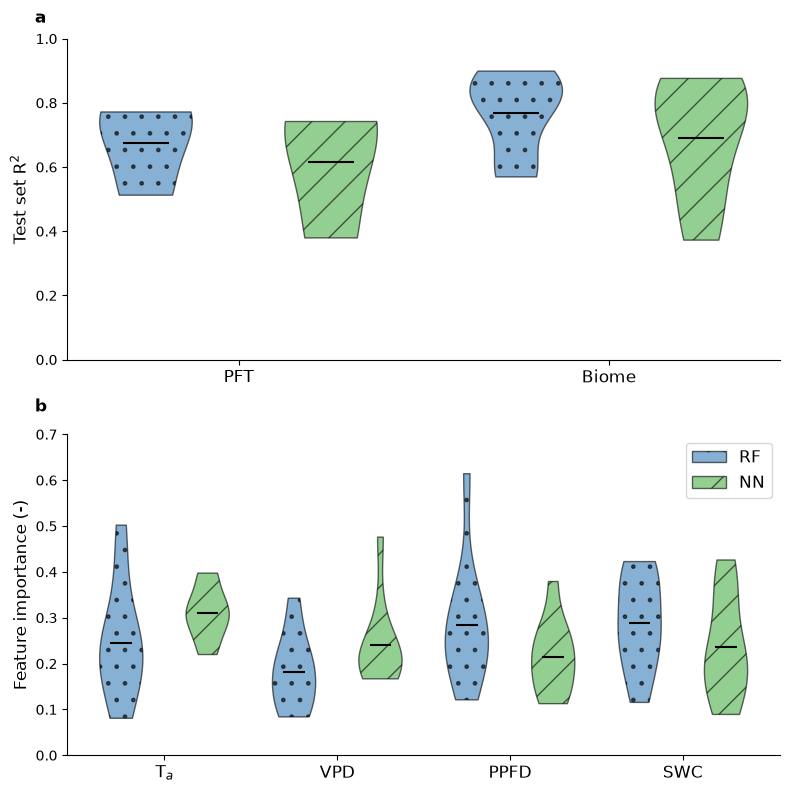

In [4]:
color1 = '#377eb8'
color2 = '#4daf4a'

fig, ax = plt.subplots(2,1, figsize = (8,8))

ax1 = ax[0]
colorlist = [color1, color2, color1, color2]
hatchlist = ['.', '/', '.', '/']

parts = ax1.violinplot([RF_PFT[' R2 test'], NN_PFT[' R2 test'], RF_biome[' R2 test'], NN_biome[' R2 test']], [0,1, 2, 3], showmeans=True, showextrema = False)
i=0
for pc in parts['bodies']:
    pc.set_facecolor(colorlist[i])
    pc.set_hatch(hatchlist[i])
    pc.set_edgecolor('black')
    pc.set_alpha(0.6)
    i +=1
    
#for m in parts['cmeans']:
parts['cmeans'].set_edgecolor('black')
    
ax1.set_xticks([0.5,2.5])
ax1.set_xticklabels(['PFT', 'Biome'], fontsize = 'large')
ax1.set_ylim(0,1)
ax1.set_ylabel('Test set R$^2$', fontsize = 'large')
ax1.text(-0.6, 1.05, 'a', fontweight = 'bold', fontsize = 'large')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2 = ax[1]

colorlist = [color1, color2, color1, color2, color1, color2, color1, color2]
hatchlist = ['.', '/', '.', '/', '.', '/', '.', '/']


parts = ax2.violinplot([RF_trim['ta'], NN_trim['ta'], RF_trim['vpd'], NN_trim['vpd'], RF_trim['ppfd_in'], NN_trim['ppfd_in'], RF_trim['swc_shallow'], NN_trim['swc_shallow']], [0,1, 2, 3, 4, 5, 6, 7], showmeans=True, showextrema = False)
ax2.set_xticks([0.5,2.5, 4.5, 6.5])
ax2.set_xticklabels(['T$_a$', 'VPD', 'PPFD', 'SWC'], fontsize = 'large')
ax2.set_ylim(0,0.7)
ax2.set_ylabel('Feature importance (-)', fontsize = 'large')
ax2.text(-1, 0.75, 'b', fontweight = 'bold', fontsize = 'large')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

i=0
for pc in parts['bodies']:
    pc.set_facecolor(colorlist[i])
    pc.set_hatch(hatchlist[i])
    pc.set_edgecolor('black')
    pc.set_alpha(0.6)
    i +=1
    
parts['cmeans'].set_edgecolor('black')

ax2.legend(['RF', 'NN'], fontsize = 'large')

fig.tight_layout()

fig.savefig('strategy_r2_feat_imp.png')

R2 RF=0.28672052891043953
Optimal Values
a: -0.004253658650819059
b: 0.8196338076353952


NameError: name 'unc' is not defined

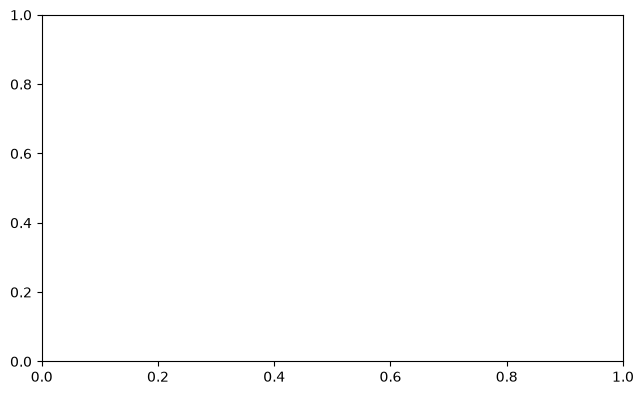

In [5]:
from sklearn.metrics import r2_score

def f(x, a, b):
    return a * x + b

fig, pt = plt.subplots(figsize = (7.5,4.5))

##--------------------------------------------------------------------------------RF

popt, pcov = curve_fit(f, RF_trim['n locations'], RF_trim[' R2 test'])

# R2 for RF

# popt, pcov = curve_fit(func, xFit, yFit)
y_pred = f(RF_trim['n locations'], *popt)
print("R2 RF=" + str(r2_score(RF_trim[' R2 test'], y_pred)))

# retrieve parameter values
a = popt[0]
b = popt[1]
print('Optimal Values')
print('a: ' + str(a))
print('b: ' + str(b))

# calculate parameter confidence interval
a,b = unc.correlated_values(popt, pcov)
print('Uncertainty')
print('a: ' + str(a))
print('b: ' + str(b))

# calculate regression confidence interval
px = np.arange(0,45,1)
py = a*px+b
nom = unp.nominal_values(py)
std = unp.std_devs(py)

# plot data RF
pt.plot(RF_PFT['n locations'], RF_PFT[' R2 test'], "s", color = color1, label = 'RF, PFT')
pt.plot(RF_biome['n locations'], RF_biome[' R2 test'], "^", color = color1, label = 'RF, biome')

# plot the regression RF
pt.plot(px, nom, c=color1)

# plot 95% confidence interval RF
pt.fill_between(px, nom - 1.96 * std, nom + 1.96 * std, color = color1, alpha = 0.5)

##--------------------------------------------------------------------------------NN
popt, pcov = curve_fit(f, NN_trim['n locations'], NN_trim[' R2 test'])

# retrieve parameter values
a = popt[0]
b = popt[1]
print('Optimal Values')
print('a: ' + str(a))
print('b: ' + str(b))

# calculate parameter confidence interval
a,b = unc.correlated_values(popt, pcov)
print('Uncertainty')
print('a: ' + str(a))
print('b: ' + str(b))

# calculate regression confidence interval
py = a*px+b
nom = unp.nominal_values(py)
std = unp.std_devs(py)

y_pred = f(NN_trim['n locations'], *popt)
print("R2 NN=" + str(r2_score(NN_trim[' R2 test'], y_pred)))

# plot data NN
pt.plot(NN_PFT['n locations'], NN_PFT[' R2 test'], "s", color = color2, label = 'NN, PFT')
pt.plot(NN_biome['n locations'], NN_biome[' R2 test'], "^", color = color2, label = 'NN, biome')

# plot the regression NN
pt.plot(px, nom, c=color2)

# plot 95% confidence interval RF
pt.fill_between(px, nom - 1.96 * std, nom + 1.96 * std, color = color2, alpha = 0.5)

pt.set_ylim(0,1)
pt.set_xlim(0,42)
pt.set_xlabel('Number of sites')
pt.set_ylabel('R$^2$')
pt.spines['top'].set_visible(False)
pt.spines['right'].set_visible(False)
pt.grid(color='grey', linestyle='-', linewidth=0.25, alpha=0.5)
pt.legend(bbox_to_anchor=(1, 0.5), loc='lower left', fontsize = 10, bbox_transform=pt.transAxes, framealpha = 1.0)
fig.tight_layout()

fig.savefig('numsites_r2.png')

In [ ]:
color1 = '#377eb8'
color2 = '#4daf4a'

NN_PFT = NN_PFT_highR2
RF_PFT = RF_PFT_highR2
NN_biome = NN_biome_highR2
RF_biome = RF_biome_highR2
NN_trim = NN_trim_highR2
RF_trim = RF_trim_highR2

fig, ax = plt.subplots(2, 2, figsize = (8.,4.5))

def f(x, a, b):
    return a * x + b

def conf_int(x_data, y_data, px):
    popt, pcov = curve_fit(f, x_data, y_data)
    # retrieve parameter values
    a = popt[0]
    b = popt[1]    
    # calculate parameter confidence interval
    a,b = unc.correlated_values(popt, pcov)
    # calculate regression confidence interval
    py = a*px+b
    nom = unp.nominal_values(py)
    std = unp.std_devs(py) 
    return py, nom, std

#--------------------------------------------------------------------------------------- a) ta feat import. vs. MAT
ax1 = ax[0,0]

# #RF
# popt, pcov = curve_fit(f, RF_trim['MAT'], RF_trim['ta'])

# # retrieve parameter values
# a = popt[0]
# b = popt[1]

# # calculate parameter confidence interval
# a,b = unc.correlated_values(popt, pcov)

# # calculate regression confidence interval
px = np.arange(0,28,1)
# py = a*px+b
# nom = unp.nominal_values(py)
# std = unp.std_devs(py)

py, nom, std = conf_int(RF_trim['MAT'], RF_trim['ta'], px)

# plot the regression RF
ax1.plot(px, nom, c=color1)

# plot 95% confidence interval RF
ax1.fill_between(px, nom - 1.96 * std, nom + 1.96 * std, color = color1, alpha = 0.5)

# plot data RF
ax1.plot(RF_PFT['MAT'], RF_PFT['ta'], "s", color = color1, label = 'RF, PFT')
ax1.plot(RF_biome['MAT'], RF_biome['ta'], "^", color = color1, label = 'RF, biome')

# # plot the regression RF
# ax1.plot(px, nom, c=color1)

# # plot 95% confidence interval RF
# ax1.fill_between(px, nom - 1.96 * std, nom + 1.96 * std, color = color1, alpha = 0.5)

#NN

popt, pcov = curve_fit(f, NN_trim['MAT'], NN_trim['ta'])

# retrieve parameter values
a = popt[0]
b = popt[1]

# calculate parameter confidence interval
a,b = unc.correlated_values(popt, pcov)

# calculate regression confidence interval
py = a*px+b
nom = unp.nominal_values(py)
std = unp.std_devs(py)

# plot data NN
ax1.plot(NN_PFT['MAT'], NN_PFT['ta'], "s", color = color2, label = 'NN, PFT')
ax1.plot(NN_biome['MAT'], NN_biome['ta'], "^", color = color2, label = 'NN, biome')

# plot the regression RF
ax1.plot(px, nom, c=color2)

# plot 95% confidence interval RF
ax1.fill_between(px, nom - 1.96 * std, nom + 1.96 * std, color = color2, alpha = 0.5)

ax1.set_ylim(0,0.7)
ax1.set_xlim(0,28)
#ax1.set_xlabel('MAT (C)')
ax1.set_ylabel('Temp. feat. import. (-)')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(color='grey', linestyle='-', linewidth=0.25, alpha=0.5)
ax1.text(-5, 0.7, 'a', fontweight = 'bold', fontsize = 'large')

#--------------------------------------------------------------------------------------- b) PPFD feat import. vs. R2
ax2 = ax[0,1]

#RF
ax2.plot(RF_PFT[' R2 test'], RF_PFT['ppfd_in'], "s", color = color1, label = 'RF, PFT')
ax2.plot(RF_biome[' R2 test'], RF_biome['ppfd_in'], "^", color = color1, label = 'RF, biome')

popt, pcov = curve_fit(f, RF_trim[' R2 test'], RF_trim['ppfd_in'])

# retrieve parameter values
a = popt[0]
b = popt[1]

# calculate parameter confidence interval
a,b = unc.correlated_values(popt, pcov)

# calculate regression confidence interval
px = np.arange(0.35,0.95,0.02)
py = a*px+b
nom = unp.nominal_values(py)
std = unp.std_devs(py)

# plot the regression RF
ax2.plot(px, nom, c=color1)

# plot 95% confidence interval RF
ax2.fill_between(px, nom - 1.96 * std, nom + 1.96 * std, color = color1, alpha = 0.5)

#NN

ax2.plot(NN_PFT[' R2 test'], NN_PFT['ppfd_in'], "s", color = color2, label = 'NN, PFT')
ax2.plot(NN_biome[' R2 test'], NN_biome['ppfd_in'], "^", color = color2, label = 'NN, biome')

popt, pcov = curve_fit(f, NN_trim[' R2 test'], NN_trim['ppfd_in'])

# retrieve parameter values
a = popt[0]
b = popt[1]

# calculate parameter confidence interval
a,b = unc.correlated_values(popt, pcov)

# calculate regression confidence interval
py = a*px+b
nom = unp.nominal_values(py)
std = unp.std_devs(py)

# plot the regression RF
ax2.plot(px, nom, c=color2)

# plot 95% confidence interval RF
ax2.fill_between(px, nom - 1.96 * std, nom + 1.96 * std, color = color2, alpha = 0.5)

ax2.set_ylim(0,0.7)
ax2.set_xlim(0.7,0.92)
#ax2.set_xlabel('Test set R$^2$')
ax2.set_ylabel('PPFD feat. import. (-)')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(color='grey', linestyle='-', linewidth=0.25, alpha=0.5)
ax2.text(0.65, 0.7, 'b', fontweight = 'bold', fontsize = 'large')

#--------------------------------------------------------------------------------------- c) PPFD feat import. vs. MAT

ax3 = ax[1,0]

#RF
ax3.plot(RF_PFT['MAT'], RF_PFT['ppfd_in'], "s", color = color1, label = 'RF, PFT')
ax3.plot(RF_biome['MAT'], RF_biome['ppfd_in'], "^", color = color1, label = 'RF, biome')

popt, pcov = curve_fit(f, RF_trim['MAT'], RF_trim['ppfd_in'])

# retrieve parameter values
a = popt[0]
b = popt[1]

# calculate parameter confidence interval
a,b = unc.correlated_values(popt, pcov)

# calculate regression confidence interval
px = np.arange(0,28,1)
py = a*px+b
nom = unp.nominal_values(py)
std = unp.std_devs(py)

# plot the regression RF
ax3.plot(px, nom, c=color1)

# plot 95% confidence interval RF
ax3.fill_between(px, nom - 1.96 * std, nom + 1.96 * std, color = color1, alpha = 0.5)

#NN
ax3.plot(NN_PFT['MAT'], NN_PFT['ppfd_in'], "s", color = color2, label = 'NN, PFT')
ax3.plot(NN_biome['MAT'], NN_biome['ppfd_in'], "^", color = color2, label = 'NN, biome')

popt, pcov = curve_fit(f, NN_trim['MAT'], NN_trim['ppfd_in'])

# retrieve parameter values
a = popt[0]
b = popt[1]

# calculate parameter confidence interval
a,b = unc.correlated_values(popt, pcov)

# calculate regression confidence interval
py = a*px+b
nom = unp.nominal_values(py)
std = unp.std_devs(py)

# plot the regression RF
ax3.plot(px, nom, c=color2)

# plot 95% confidence interval RF
ax3.fill_between(px, nom - 1.96 * std, nom + 1.96 * std, color = color2, alpha = 0.5)

ax3.set_ylim(0,0.7)
ax3.set_xlim(0,28)
ax3.set_xlabel('MAT (C)')
ax3.set_ylabel('PPFD feat. import. (-)')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(color='grey', linestyle='-', linewidth=0.25, alpha=0.5)
ax3.text(-5, 0.7, 'c', fontweight = 'bold', fontsize = 'large')

#--------------------------------------------------------------------------------------- d) SWC feat import. vs. R2
ax4 = ax[1,1]

#RF
ax4.plot(RF_PFT[' R2 test'], RF_PFT['swc_shallow'], "s", color = color1, label = 'RF, PFT')
ax4.plot(RF_biome[' R2 test'], RF_biome['swc_shallow'], "^", color = color1, label = 'RF, biome')

popt, pcov = curve_fit(f, RF_trim[' R2 test'], RF_trim['swc_shallow'])

# retrieve parameter values
a = popt[0]
b = popt[1]

# calculate parameter confidence interval
a,b = unc.correlated_values(popt, pcov)

# calculate regression confidence interval
px = np.arange(0.35,0.95,0.02)
py = a*px+b
nom = unp.nominal_values(py)
std = unp.std_devs(py)

# plot the regression RF
ax4.plot(px, nom, c=color1)

# plot 95% confidence interval RF
ax4.fill_between(px, nom - 1.96 * std, nom + 1.96 * std, color = color1, alpha = 0.5)

#NN

ax4.plot(NN_PFT[' R2 test'], NN_PFT['swc_shallow'], "s", color = color2, label = 'NN, PFT')
ax4.plot(NN_biome[' R2 test'], NN_biome['swc_shallow'], "^", color = color2, label = 'NN, biome')

popt, pcov = curve_fit(f, NN_trim[' R2 test'], NN_trim['swc_shallow'])

# retrieve parameter values
a = popt[0]
b = popt[1]

# calculate parameter confidence interval
a,b = unc.correlated_values(popt, pcov)

# calculate regression confidence interval
py = a*px+b
nom = unp.nominal_values(py)
std = unp.std_devs(py)

# plot the regression RF
ax4.plot(px, nom, c=color2)

# plot 95% confidence interval RF
ax4.fill_between(px, nom - 1.96 * std, nom + 1.96 * std, color = color2, alpha = 0.5)

ax4.set_ylim(0,0.7)
ax4.set_xlim(0.7,0.92)
ax4.set_xlabel('Test set R$^2$')
ax4.set_ylabel('SWC feat. import. (-)')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.grid(color='grey', linestyle='-', linewidth=0.25, alpha=0.5)
ax4.text(0.65, 0.7, 'd', fontweight = 'bold', fontsize = 'large')
ax4.legend(bbox_to_anchor=(1, 0.5), loc='lower left', fontsize = 10, bbox_transform=ax4.transAxes, framealpha = 1.0)

fig.tight_layout()
fig.savefig('correlations_mat_r2.png', dpi=300)

In [ ]:
def f(x, a, b):
    return a * x + b

def conf_int(x_data, y_data, px):
    popt, pcov = curve_fit(f, x_data, y_data)
    # retrieve parameter values
    a = popt[0]
    b = popt[1]    
    # calculate parameter confidence interval
    a,b = unc.correlated_values(popt, pcov)
    # calculate regression confidence interval
    py = a*px+b
    nom = unp.nominal_values(py)
    std = unp.std_devs(py) 
    return py, nom, std
    

fig, ax = plt.subplots(2, 2, figsize = (8,4.5))

#---------------------------------------------------------------------------------------------a) MAP vs. SWC feat import
ax1 = ax[0,0]

ax1.plot(RF_PFT['MAP'], RF_PFT['swc_shallow'], "s", color = color1, label = 'RF, PFT')
ax1.plot(RF_biome['MAP'], RF_biome['swc_shallow'], "^", color = color1, label = 'RF, biome')

px = np.arange(0, 3100, 1)

py, nom, std = conf_int(RF_trim['MAP'], RF_trim['swc_shallow'], px)

# plot the regression RF
ax1.plot(px, nom, c=color1)

# plot 95% confidence interval RF
ax1.fill_between(px, nom - 1.96 * std, nom + 1.96 * std, color = color1, alpha = 0.5)

ax1.plot(NN_PFT['MAP'], NN_PFT['swc_shallow'], "s", color = color2, label = 'NN, PFT')
ax1.plot(NN_biome['MAP'], NN_biome['swc_shallow'], "^", color = color2, label = 'NN, biome')

py, nom, std = conf_int(NN_trim['MAP'], NN_trim['swc_shallow'], px)

# plot the regression NN
ax1.plot(px, nom, c=color2)

# plot 95% confidence interval NN
ax1.fill_between(px, nom - 1.96 * std, nom + 1.96 * std, color = color2, alpha = 0.5)

ax1.set_xlim(0,3100)
ax1.set_ylim(0,0.5)
ax1.set_xlabel('MAP (mm)')
ax1.set_ylabel('SWC feat. import. (-)')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(color='grey', linestyle='-', linewidth=0.25, alpha=0.5)
ax1.text(-310, 0.55, 'a', fontweight = 'bold', fontsize = 'large')

#---------------------------------------------------------------------------------------------b) SWCavg vs. SWC feat import
ax2 = ax[0,1]

ax2.plot(RF_PFT['swc_shallow_avg'], RF_PFT['swc_shallow'], "s", color = color1, label = 'RF, PFT')
ax2.plot(RF_biome['swc_shallow_avg'], RF_biome['swc_shallow'], "^", color = color1, label = 'RF, biome')

px = np.arange(0.05, 0.32, 0.02)

py, nom, std = conf_int(RF_trim['swc_shallow_avg'], RF_trim['swc_shallow'], px)

# plot the regression RF
ax2.plot(px, nom, c=color1)

# plot 95% confidence interval RF
ax2.fill_between(px, nom - 1.96 * std, nom + 1.96 * std, color = color1, alpha = 0.5)

ax2.plot(NN_PFT['swc_shallow_avg'], NN_PFT['swc_shallow'], "s", color = color2, label = 'NN, PFT')
ax2.plot(NN_biome['swc_shallow_avg'], NN_biome['swc_shallow'], "^", color = color2, label = 'NN, biome')


py, nom, std = conf_int(NN_trim['swc_shallow_avg'], NN_trim['swc_shallow'], px)

ax2.plot(px, nom, c=color2)

ax2.fill_between(px, nom - 1.96 * std, nom + 1.96 * std, color = color2, alpha = 0.5)

ax2.set_xlim(0.05, 0.32)
ax2.set_ylim(0,0.5)
ax2.set_xlabel('Mean SWC (-)')
#ax2.set_ylabel('SWC feat. import. (-)')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(color='grey', linestyle='-', linewidth=0.25, alpha=0.5)
ax2.text(0.02, 0.55, 'b', fontweight = 'bold', fontsize = 'large')

#---------------------------------------------------------------------------------------------c) SFavg vs. SWC feat import
ax3 = ax[1,0]

ax3.plot(RF_PFT['Sap flux average'], RF_PFT['swc_shallow'], "s", color = color1, label = 'RF, PFT')
ax3.plot(RF_biome['Sap flux average'], RF_biome['swc_shallow'], "^", color = color1, label = 'RF, biome')

px = np.arange(0, 4800, 1)

py, nom, std = conf_int(RF_trim['Sap flux average'], RF_trim['swc_shallow'], px)

ax3.plot(px, nom, c=color1)

ax3.fill_between(px, nom - 1.96 * std, nom + 1.96 * std, color = color1, alpha = 0.5)

ax3.plot(NN_PFT['Sap flux average'], NN_PFT['swc_shallow'], "s", color = color2, label = 'NN, PFT')
ax3.plot(NN_biome['Sap flux average'], NN_biome['swc_shallow'], "^", color = color2, label = 'NN, biome')

py, nom, std = conf_int(NN_trim['Sap flux average'], NN_trim['swc_shallow'], px)

ax3.plot(px, nom, c=color2)

ax3.fill_between(px, nom - 1.96 * std, nom + 1.96 * std, color = color2, alpha = 0.5)

ax3.set_xlim(0,4800)
ax3.set_ylim(0,0.5)
ax3.set_xlabel('Mean sap flux (cm$^3$/hr)')
ax3.set_ylabel('SWC feat. import. (-)')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(color='grey', linestyle='-', linewidth=0.25, alpha=0.5)
ax3.text(-450, 0.55, 'c', fontweight = 'bold', fontsize = 'large')


#---------------------------------------------------------------------------------------------d) VPDavg vs. SWC feat import
ax4 = ax[1,1]

ax4.plot(RF_PFT['vpd_avg'], RF_PFT['swc_shallow'], "s", color = color1, label = 'RF, PFT')
ax4.plot(RF_biome['vpd_avg'], RF_biome['swc_shallow'], "^", color = color1, label = 'RF, biome')

px = np.arange(0.24, 1.5, 0.05)

py, nom, std = conf_int(RF_trim['vpd_avg'], RF_trim['swc_shallow'], px)

ax4.plot(px, nom, c=color1)

ax4.fill_between(px, nom - 1.96 * std, nom + 1.96 * std, color = color1, alpha = 0.5)


ax4.plot(NN_PFT['vpd_avg'], NN_PFT['swc_shallow'], "s", color = color2, label = 'NN, PFT')
ax4.plot(NN_biome['vpd_avg'], NN_biome['swc_shallow'], "^", color = color2, label = 'NN, biome')

py, nom, std = conf_int(NN_trim['vpd_avg'], NN_trim['swc_shallow'], px)

ax4.plot(px, nom, c=color2)

ax4.fill_between(px, nom - 1.96 * std, nom + 1.96 * std, color = color2, alpha = 0.5)

ax4.set_ylim(0,0.5)
ax4.set_xlim(0.24,1.5)
ax4.set_xlabel('Mean VPD (kPa)')
#ax4.set_ylabel('SWC feat. import. (-)')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.grid(color='grey', linestyle='-', linewidth=0.25, alpha=0.5)
ax4.text(0.11, 0.55, 'd', fontweight = 'bold', fontsize = 'large')
ax4.legend(bbox_to_anchor=(1, 0.5), loc='lower left', fontsize = 10, bbox_transform=ax4.transAxes, framealpha = 1.0)




fig.tight_layout()

fig.savefig('correlations_swc_import.png', dpi = 300)

*Correlation matrix*

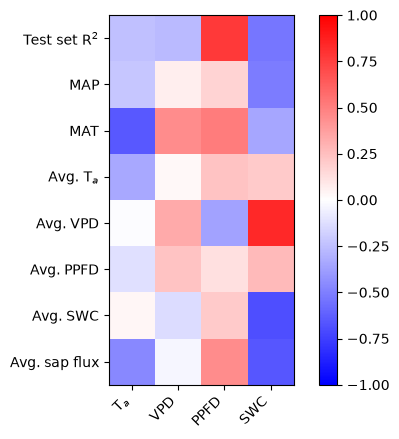

In [7]:
import matplotlib as matplotlib
import matplotlib.pyplot as plt

# collect data
data = {
    'Ta': [-.244, -.223, -0.655, -0.341, -0.012, -0.122, 0.037, -0.463],
    'VPD': [-0.268, .064, .448, .024, .329, .232, -.134, -0.037],
    'PPFD': [.768, .168, .515, .232, -.366, .122, .207, .451],
    'SWC': [-.537, -.509, -.345, .207, .841, .268, -.695, -.659]
}

# form dataframe
dataframe = pd.DataFrame(data, columns=['Ta', 'VPD', 'PPFD', 'SWC'])

matrix = dataframe.to_numpy()
# form correlation matrix
#matrix = dataframe.corr()
#print("Correlation matrix is : ")
#print(matrix)

fig = plt.figure()
plt.imshow(matrix, cmap='bwr', vmin = -1, vmax = 1)
plt.colorbar()
plt.xticks(range(4), ['T$_a$', 'VPD', 'PPFD', 'SWC'], rotation=45, ha='right')
plt.yticks(range(8), ['Test set R$^2$', 'MAP', 'MAT', 'Avg. T$_a$', 'Avg. VPD', 'Avg. PPFD', 'Avg. SWC', 'Avg. sap flux'])
plt.show()
fig.savefig('feat_climate_correlation.tiff', dpi = 300)


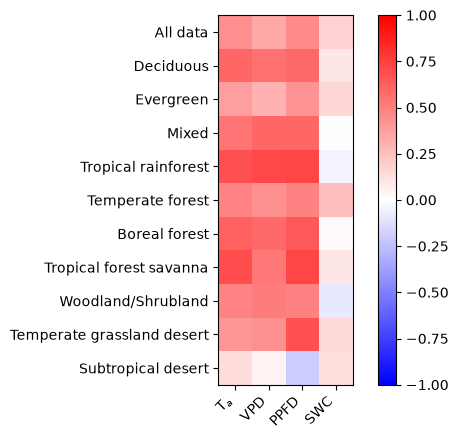

In [6]:
# collect data
data = {
    'Ta': [0.44, 0.60, 0.38, 0.54, 0.48, 0.48, 0.68, 0.70, 0.14, 0.61, 0.41],
    'VPD': [0.34, 0.56, 0.30, 0.60, 0.51, 0.43, 0.71, 0.53, 0.05, 0.58, 0.43],
    'PPFD': [0.46, 0.59, 0.42, 0.60, 0.49, 0.49, 0.72, 0.72, -0.20, 0.65, 0.68],
    'SWC': [0.17, 0.10, 0.16, 0.00, -0.09, 0.25, -0.04, 0.10, 0.13, 0.02, 0.15]
}

# form dataframe
dataframe = pd.DataFrame(data, columns=['Ta', 'VPD', 'PPFD', 'SWC'])
dataframe_sort = dataframe.reindex([0,1,2,3,6,5,9,7,4,10,8])

matrix = dataframe_sort.to_numpy()
# form correlation matrix
#matrix = dataframe.corr()
#print("Correlation matrix is : ")
#print(matrix)

fig = plt.figure()
plt.imshow(matrix, cmap='bwr', vmin = -1, vmax = 1)
plt.colorbar()
plt.xticks(range(4), ['T$_a$', 'VPD', 'PPFD', 'SWC'], rotation=45, ha='right')
plt.yticks(range(11), ['All data', 'Deciduous', 'Evergreen', 'Mixed', 'Tropical rainforest', 'Temperate forest', 'Boreal forest', 'Tropical forest savanna', 'Woodland/Shrubland',   'Temperate grassland desert',  'Subtropical desert'])
plt.show()
fig.savefig('transpiration_correlation.tiff', dpi = 300)